In [8]:
from langgraph.graph import StateGraph,START,END 
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from typing import TypedDict , Annotated
import operator
from pydantic import BaseModel , Field

In [9]:
load_dotenv()
model = ChatMistralAI(model_name="ministral-3b-latest", temperature=0.7)

In [10]:
class EvaluationSchema(BaseModel):

    feedback:str = Field(description = "Detailed feedback for the essay")
    score:int = Field(description = "Score out of 10",ge = 0 , le = 10)


In [11]:
structured_model = model.with_structured_output(EvaluationSchema)

In [12]:
essay = """Artificial Intelligence (AI) is rapidly transforming India, driving the nation toward its goal of becoming a technologically advanced and self-reliant country, often envisioned as 'Viksit Bharat'. By reshaping key sectors like agriculture, healthcare, and education, AI acts as a powerful catalyst for inclusive economic growth.In agriculture, AI-powered tools help farmers analyze soil health, predict weather patterns, and monitor crops, which drastically improves productivity. Healthcare in India is becoming more accessible and affordable through AI-driven telemedicine, early disease detection, and personalized treatment plans, bridging the gap between urban and rural areas. Furthermore, AI is revolutionizing education by offering personalized learning experiences and virtual tutoring, ensuring that quality education reaches remote villages.Beyond these social sectors, AI enhances public governance through smart city initiatives, efficient digital service delivery, and robust data management. However, this rapid integration also brings challenges, including data privacy concerns, the digital divide, and potential job displacement in traditional sectors.To maximize its potential, India must focus on ethical AI frameworks and intensive skill-development programs. Ultimately, if balanced responsibly, AI will continue to act as a major cornerstone for India’s future development, global leadership, and economic prosperity."""

In [13]:
prompt = f'Evalute the language quality of the following essay and provide a feedback and assign a score out of 10 .\n {essay}'
structured_model.invoke(prompt).feedback

"The essay provides a clear and concise overview of how Artificial Intelligence (AI) is transforming India across multiple sectors like agriculture, healthcare, education, and public governance. The language is coherent, engaging, and well-structured, with a logical flow from one topic to another. Here are some specific strengths:\n\n1. **Clarity and Precision**: The essay effectively communicates complex ideas in simple and understandable terms. Phrases like 'driving the nation toward its goal of becoming a technologically advanced and self-reliant country' and 'reshaping key sectors' are impactful.\n\n2. **Relevance**: The examples provided—such as AI-powered tools in agriculture, telemedicine in healthcare, and personalized learning in education—are relevant and well-chosen, demonstrating the broad impact of AI.\n\n3. **Balanced Perspective**: The essay acknowledges both the benefits and challenges of AI integration in India, which adds depth to the discussion. The mention of data p

In [14]:
class UPSCState(TypedDict):
    essay :str
    language_feedback : str
    anlysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    indivisual_score : Annotated[list[int], operator.add]
    avg_score : float

In [26]:
def evaluate_language(state:UPSCState):
    prompt = f'Evalute the language quality of the following essay and provide a feedback and assign a score out of 10 .\n {essay}'
    output = structured_model.invoke(prompt)
    return {'language_feedback':output.feedback , 'indivisual_score':[output.score]}

In [27]:
def evaluate_analysis(state:UPSCState):
    prompt = f'Evalute the depth of anlysis of the following essay and provide a feedback and assign a score out of 10 .\n {essay}'
    output = structured_model.invoke(prompt)
    return {'anlysis_feedback':output.feedback , 'indivisual_score':[output.score]}

In [28]:
def evaluate_clarity(state:UPSCState):
    prompt = f'Evalute the calrity of thought of the following essay and provide a feedback and assign a score out of 10 .\n {essay}'
    output = structured_model.invoke(prompt)
    return {'clarity_feedback':output.feedback , 'indivisual_score':[output.score]}

In [29]:
def final_eval(state:UPSCState):
    prompt = f'based on the following feedback create a summarized feedback \n language feedback - {state["language_feedback"]} \n analysis_feedback - {state["anlysis_feedback"]} \n clarity_feedback - {state["clarity_feedback"]}'
    final_feedback = model.invoke(prompt).content
    avg_score = sum(state['indivisual_score'])/len(state['indivisual_score'])

    return {'overall_feedback':final_feedback , 'avg_score':avg_score}

In [30]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_eval', final_eval)

graph.add_edge(START , 'evaluate_language')
graph.add_edge(START ,'evaluate_analysis')
graph.add_edge(START , 'evaluate_clarity')
graph.add_edge('evaluate_language' , 'final_eval')
graph.add_edge('evaluate_analysis' , 'final_eval')
graph.add_edge('evaluate_clarity' , 'final_eval')
graph.add_edge('final_eval' ,END)

workflow = graph.compile()


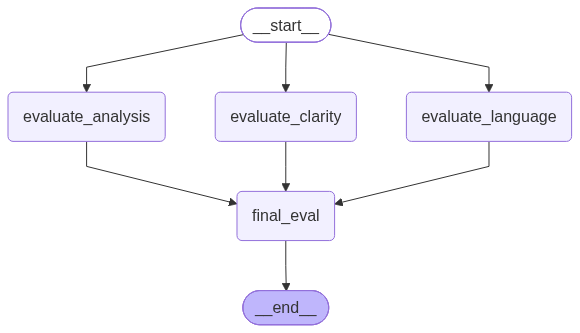

In [31]:
workflow

In [32]:
initial_state = {
    'essay' : essay
}

workflow.invoke(initial_state) 

{'essay': "Artificial Intelligence (AI) is rapidly transforming India, driving the nation toward its goal of becoming a technologically advanced and self-reliant country, often envisioned as 'Viksit Bharat'. By reshaping key sectors like agriculture, healthcare, and education, AI acts as a powerful catalyst for inclusive economic growth.In agriculture, AI-powered tools help farmers analyze soil health, predict weather patterns, and monitor crops, which drastically improves productivity. Healthcare in India is becoming more accessible and affordable through AI-driven telemedicine, early disease detection, and personalized treatment plans, bridging the gap between urban and rural areas. Furthermore, AI is revolutionizing education by offering personalized learning experiences and virtual tutoring, ensuring that quality education reaches remote villages.Beyond these social sectors, AI enhances public governance through smart city initiatives, efficient digital service delivery, and robust